# Entrenamiento del modelo de detección de productos frescos

Este notebook sirve ha sido el usado para entrenar el modelo final de deteccion de productos frescos

In [41]:
# CELDA 1 — Instalar dependencias
#
# Si tienes CUDA 12.8 (RTX 5060 / drivers CUDA 13.x):
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
#
# Dependencias del notebook:
# !pip install ultralytics onnx onnxruntime onnxsim opencv-python matplotlib pandas tqdm
#

In [42]:

# CELDA 2 - Verificar GPU y versiones
import torch
import numpy as np
import json, os, shutil, random, time
from pathlib import Path

print(f'PyTorch: {torch.__version__}')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nDispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM: {vram:.1f} GB')
else:
    print('Sin GPU el entrenamiento tardara mas (CPU)')

PyTorch: 2.11.0+cu128

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.5 GB


In [ ]:
# CELDA 3 - Configuracion
DATASET_DIR = 'fruits-360'
GROUPED_DIR = 'fruits-360-grouped'
OUTPUT_DIR = 'modelo_entrenado'

IMG_SIZE = 224 # resolucion de entrada
BATCH_SIZE = 128

# Directorios (deberemos tener instalada de kaggle fruits-360)
TRAIN_DIR = os.path.join(DATASET_DIR, 'Training')
VAL_DIR   = os.path.join(DATASET_DIR, 'Validation')
TEST_DIR  = os.path.join(DATASET_DIR, 'Test')

os.makedirs(OUTPUT_DIR, exist_ok=True)

for nombre, ruta in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    existe = os.path.isdir(ruta)
    print(f'{nombre:5s}: {ruta} (existe: {existe})')
print(f'Batch: {BATCH_SIZE} | Img size: {IMG_SIZE}')
if not os.path.isdir(TRAIN_DIR):
    print('\n[ERROR] No se encontro el dataset. Revisa DATASET_DIR.')

Train: fruits-360\Training (existe: True)
Val  : fruits-360\Validation (existe: True)
Test : fruits-360\Test (existe: True)
Batch: 128 | Img size: 224


In [23]:
# CELDA 4 - Verificar dataset y sanity checks
from torchvision import datasets

total_imgs = 0
for nombre, ruta in [('Training', TRAIN_DIR), ('Test', TEST_DIR), ('Validation', VAL_DIR)]:
    if not os.path.isdir(ruta):
        print(f'{nombre:12s}: NO ENCONTRADO')
        continue
    ds     = datasets.ImageFolder(ruta)
    clases = len(ds.classes)
    imgs   = len(ds)
    total_imgs += imgs
    print(f'{nombre:12s}: {imgs:>6,} imagenes  |  {clases} clases')
print(f'{"TOTAL":12s}: {total_imgs:>6,} imagenes')

print()
clases_train = set(datasets.ImageFolder(TRAIN_DIR).classes) if os.path.isdir(TRAIN_DIR) else set()
clases_test = set(datasets.ImageFolder(TEST_DIR).classes) if os.path.isdir(TEST_DIR) else set()
clases_val = set(datasets.ImageFolder(VAL_DIR).classes) if os.path.isdir(VAL_DIR) else set()

solo_en_test = clases_test - clases_train
solo_en_val  = clases_val  - clases_train

if not solo_en_test and not solo_en_val:
    print('Clases consistentes entre directorios OK')

print()
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU lista: {torch.cuda.get_device_name(0)}  ({vram:.1f} GB VRAM) OK')
else:
    print('[AVISO] Sin GPU el entrenamiento sera muy lento')

Training    : 49,806 imagenes  |  140 clases
Test        : 24,758 imagenes  |  140 clases
Validation  : 24,910 imagenes  |  140 clases
TOTAL       : 99,474 imagenes


GPU lista: NVIDIA GeForce RTX 5060 Laptop GPU  (8.5 GB VRAM) OK


In [24]:
# CELDA 5- Mapeo de clases y funcion para construir el directorio agrupado

GRUPOS_LABEL = {
    "almond":     "Almond",     "apple":     "Apple",
    "avocado":    "Avocado",    "banana":    "Banana",
    "beans":      "Beans",      "blackberry":"Blackberry",
    "cabbage":    "Cabbage",    "cactus":    "Cactus fruit",
    "caju":       "Caju",       "cantaloupe":"Melon",
    "carambola":  "Carambola",  "carrot":    "Carrot",
    "cherimoya":  "Cherimoya",  "cherry":    "Cherry",
    "cucumber":   "Cucumber",   "dates":     "Dates",
    "eggplant":   "Eggplant",   "ginger":    "Ginger",
    "gooseberry": "Gooseberry", "grape":     "Grape",
    "nectarine":  "Nectarine",  "nut":       "Nut",
    "onion":      "Onion",      "orange":    "Orange",
    "papaya":     "Papaya",     "peach":     "Peach",
    "pear":       "Pear",       "pepper":    "Pepper",
    "pistachio":  "Pistachio",  "plum":      "Plum",
    "quince":     "Quince",     "raspberry": "Raspberry",
    "strawberry": "Strawberry", "tomato":    "Tomato",
    "zucchini":   "Zucchini",
}

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def _get_grupo(nombre_carpeta: str):
    lower = nombre_carpeta.lower()
    for clave, grupo in GRUPOS_LABEL.items():
        if clave in lower:
            return grupo
    return None

def build_grouped_split(src_dir: str, split_name: str, grouped_root: str, force: bool = False) -> tuple:
    """
    Copia imagenes de src_dir al directorio grouped_root/split_name/
    organizadas por clase canonica
    """
    dst_root = os.path.join(grouped_root, split_name)

    if os.path.isdir(dst_root) and not force:
        n = sum(len(f) for _, _, f in os.walk(dst_root))
        clases = sorted(d for d in os.listdir(dst_root)
                        if os.path.isdir(os.path.join(dst_root, d)))
        print(f'{split_name:5s}: ya existe ({n:,} imgs, {len(clases)} clases)')
        return n, set(clases)

    os.makedirs(dst_root, exist_ok=True)
    n_copiadas, clases_vistas = 0, set()

    carpetas = sorted(
        d for d in os.listdir(src_dir)
        if os.path.isdir(os.path.join(src_dir, d))
    )
    for carpeta in carpetas:
        grupo = _get_grupo(carpeta)
        if grupo is None:
            continue
        clases_vistas.add(grupo)
        dst_class = os.path.join(dst_root, grupo)
        os.makedirs(dst_class, exist_ok=True)
        src_class = os.path.join(src_dir, carpeta)
        for fname in os.listdir(src_class):
            if os.path.splitext(fname)[1].lower() in IMG_EXTS:
                # Prefijo con nombre de carpeta para evitar colisiones de nombre
                shutil.copy2(
                    os.path.join(src_class, fname),
                    os.path.join(dst_class, f'{carpeta}_{fname}'),
                )
                n_copiadas += 1

    print(f'  {split_name:5s}: {n_copiadas:,} imgs copiadas  ({len(clases_vistas)} clases)')
    return n_copiadas, clases_vistas


print('Funciones de agrupamiento definidas.')
print(f'Clases canonicas configuradas: {len(GRUPOS_LABEL)}')

Funciones de agrupamiento definidas.
Clases canonicas configuradas: 35


In [25]:
# CELDA 6 - Construir el directorio agrupado
print(f'Construyendo {GROUPED_DIR}/\n')

n_train, clases_train = build_grouped_split(TRAIN_DIR, 'train', GROUPED_DIR)
n_val,   clases_val   = build_grouped_split(VAL_DIR,   'val',   GROUPED_DIR)
n_test,  clases_test  = build_grouped_split(TEST_DIR,  'test',  GROUPED_DIR)

print(f'\nTotal: {n_train + n_val + n_test:,} imagenes')
print(f'Clases en train: {len(clases_train)}')

only_train = clases_train - clases_val
only_val   = clases_val   - clases_train
if only_train:
    print(f'[AVISO] Solo en train: {only_train}')
if only_val:
    print(f'[AVISO] Solo en val: {only_val}')
if not only_train and not only_val:
    print('Clases coherentes entre train y val OK')

Construyendo fruits-360-grouped/

train: ya existe (99,540 imgs, 34 clases)
val  : ya existe (24,832 imgs, 34 clases)
test : ya existe (24,681 imgs, 34 clases)

Total: 149,053 imagenes
Clases en train: 34
Clases coherentes entre train y val OK


In [ ]:
# CELDA 7 - Augmentación de fondo (background augmentation)

# Se hace para solucionar el problema de que Fruits-360 tiene SIEMPRE fondo blanco

import os
import cv2
import numpy as np
import random
from pathlib import Path

RATIO_AUG = 1.0
AUG_FLAG = '_bgaug'
UMBRAL_BLANCO = 230 

MIT_BASE = r'C:\Users\marcos\VisualCode\TFG\tfg-iot-frigorifico\kaggle_tmp\indoorCVPR_09\Images'

COCINAS = {'kitchen', 'restaurant_kitchen', 'pantry'}
HOGAR   = {'livingroom', 'bedroom', 'dining_room', 'corridor',
           'bathroom', 'children_room', 'closet', 'nursery'}
PESO_COCINA = 3
PESO_HOGAR  = 1

bg_cocina, bg_hogar = [], []

if os.path.isdir(MIT_BASE):
    for cat in os.listdir(MIT_BASE):
        cat_dir = os.path.join(MIT_BASE, cat)
        if not os.path.isdir(cat_dir):
            continue
        imgs = [
            os.path.join(cat_dir, f)
            for f in os.listdir(cat_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        cl = cat.lower()
        if cl in COCINAS:
            bg_cocina.extend(imgs)
        elif cl in HOGAR:
            bg_hogar.extend(imgs)
else:
    print(f'[AVISO] MIT Indoor Scenes no encontrado en:\n  {MIT_BASE}')
    print(' Descárgalo de Kaggle: ameerpetkar/mit-indoor-scenes')

pool_bg = bg_cocina * PESO_COCINA + bg_hogar * PESO_HOGAR
print(f'Fondos disponibles: {len(bg_cocina)} cocina {len(bg_hogar)} hogar → pool={len(pool_bg)}')

def aplicar_fondo(fruta_bgr: np.ndarray, fondo_path: str) -> np.ndarray:
    """Sustituye píxeles blancos de fruta_bgr con píxeles del fondo real."""
    fondo_bgr = cv2.imread(fondo_path)
    if fondo_bgr is None:
        return fruta_bgr
    h, w = fruta_bgr.shape[:2]
    fondo = cv2.resize(fondo_bgr, (w, h))
    mascara = np.all(fruta_bgr > UMBRAL_BLANCO, axis=2)
    resultado = fruta_bgr.copy()
    resultado[mascara] = fondo[mascara]
    return resultado

train_dir = os.path.join(GROUPED_DIR, 'train')

if not pool_bg:
    print('[SKIP] Sin fondos — omitiendo augmentación. Descarga MIT Indoor Scenes.')
else:
    clases = sorted(os.listdir(train_dir))
    total_nuevas = 0
    total_ya     = 0

    for clase in clases:
        clase_dir = os.path.join(train_dir, clase)
        if not os.path.isdir(clase_dir):
            continue
        if 'nofruta' in clase.lower():
            continue  # NoFruta ya tiene fondos reales

        originales = [
            f for f in os.listdir(clase_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png')) and AUG_FLAG not in f
        ]
        if not originales:
            continue

        n_aug_objetivo = int(len(originales) * RATIO_AUG)
        ya_existen = sum(1 for f in os.listdir(clase_dir) if AUG_FLAG in f)

        if ya_existen >= n_aug_objetivo:
            total_ya += ya_existen
            continue

        faltan   = n_aug_objetivo - ya_existen

        # Elegir aleatoriamente qué originales augmentar (sin repetir índice de nombre)
        muestras = random.choices(originales, k=faltan)
        generadas = 0

        for i, nombre in enumerate(muestras):
            fruta = cv2.imread(os.path.join(clase_dir, nombre))
            if fruta is None:
                continue
            aug  = aplicar_fondo(fruta, random.choice(pool_bg))
            stem = Path(nombre).stem
            dst  = os.path.join(clase_dir, f'{stem}_{i:05d}{AUG_FLAG}.jpg')
            cv2.imwrite(dst, aug, [cv2.IMWRITE_JPEG_QUALITY, 92])
            generadas += 1

        total_nuevas += generadas
        pct_real = (ya_existen + generadas) / (len(originales) + ya_existen + generadas) * 100
        print(f'  {clase:<20s}: {len(originales)} orig  +{generadas} bgaug  ({pct_real:.0f}% fondo real)')

    print(f'\nAugmentación completada.')
    print(f'Nuevas imágenes: {total_nuevas}')
    print(f'Ya existían : {total_ya}')
    print(f'Ratio fondo real : ~{RATIO_AUG/(1+RATIO_AUG)*100:.0f}% del total de train')
    print('Solo train/ modificado — val/ y test/ permanecen limpios.')

    # Invalidar caché de ultralytics para que reescanee train/
    cache_train = Path(GROUPED_DIR) / 'train.cache'
    if cache_train.exists():
        cache_train.unlink()
        print(f'  Cache borrado: {cache_train}')


Fondos disponibles: 1225 cocina 2576 hogar → pool=6251

Augmentación completada.
Nuevas imágenes: 0
Ya existían : 49889
Ratio fondo real : ~50% del total de train
Solo train/ modificado — val/ y test/ permanecen limpios.


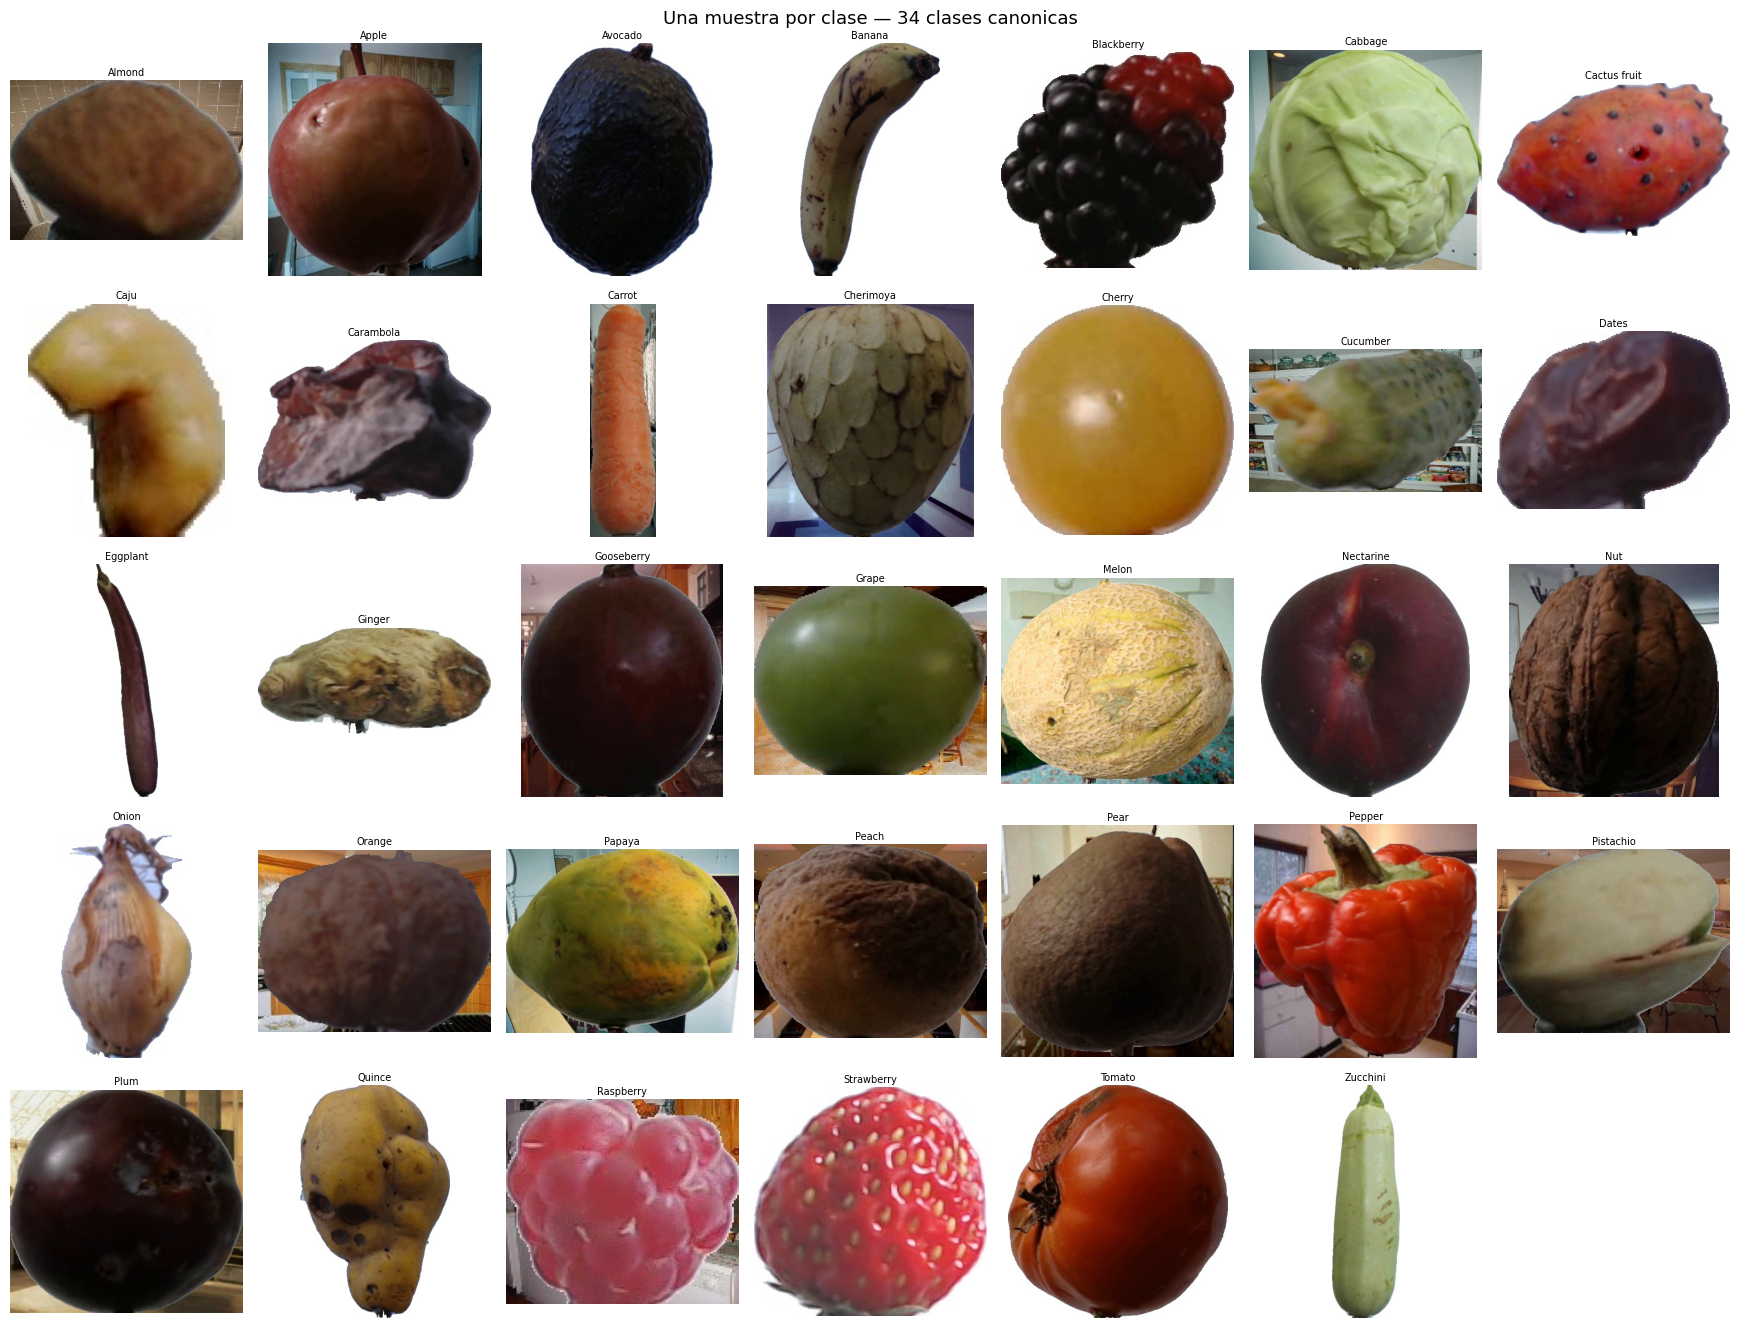

In [27]:
# CELDA 8 - Visualizar una muestra por clase del dataset agrupado
import matplotlib.pyplot as plt
import cv2

clases_sorted     = sorted(clases_train)
train_split_path  = os.path.join(GROUPED_DIR, 'train')

cols = 7
rows = (len(clases_sorted) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.7))
fig.suptitle(f'Una muestra por clase — {len(clases_sorted)} clases canonicas', fontsize=13)

for ax, clase in zip(axes.flatten(), clases_sorted):
    clase_dir = os.path.join(train_split_path, clase)
    fnames    = [f for f in os.listdir(clase_dir)
                 if os.path.splitext(f)[1].lower() in IMG_EXTS]
    img = cv2.imread(os.path.join(clase_dir, random.choice(fnames)))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(clase, fontsize=7, pad=3)
    ax.axis('off')

for ax in axes.flatten()[len(clases_sorted):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'muestras_clases.png'), dpi=100, bbox_inches='tight')
plt.show()

In [28]:
# CELDA 9 - Configuración del modelo y flags de entrenamiento

ENTRENAR = False
MODELO_BASE = 'efficientnet_b0'
EPOCHS_FASE1 = 2
EPOCHS_FASE2 = 4
LR_FASE1 = 1e-3
LR_FASE2 = 1e-4


In [29]:
# CELDA 10 — Fine-tuning en dos fases con PyTorch + torchvision

# FASE 1: backbone congelado, solo se entrena la cabeza clasificadora
# FASE 2: se descongelan SOLO las últimas capas del backbone (~30% params)

# Sin early stopping
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from copy import deepcopy

_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

# DataLoaders
train_ds = datasets.ImageFolder(os.path.join(GROUPED_DIR, 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(GROUPED_DIR, 'val'),   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=False)

num_classes = len(train_ds.classes)
class_names = train_ds.classes
print(f'Clases: {num_classes}  |  Train: {len(train_ds):,} imgs  |  Val: {len(val_ds):,} imgs')

# Creación del modelo
def _crear_modelo(nombre, n_clases):
    # Dependiendo del nombre del modelo entrenamos uno o otro, se uso para encontrar el mejor modelo final
    if nombre == 'efficientnet_b0':
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, n_clases)
        cabeza = list(m.classifier.parameters())
    elif nombre == 'resnet18':
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, n_clases)
        cabeza = list(m.fc.parameters())
    elif nombre == 'mobilenet_v3_small':
        m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, n_clases)
        cabeza = list(m.classifier.parameters())
    else:
        raise ValueError(f'Modelo no soportado: {nombre}')
    backbone = [p for p in m.parameters() if not any(p is q for q in cabeza)]
    return m, cabeza, backbone

# Descongelado parcial para Fase 2
def _descongelar_parcial(model, nombre):
    """
    Descongela solo las últimas capas para reducir VRAM en Fase 2
    """
    if nombre == 'efficientnet_b0':
        # ~30% params
        activos = {f'features.{i}' for i in range(6, 9)} | {'classifier'}
    elif nombre == 'resnet18':
        activos = {'layer3', 'layer4', 'fc'}
    elif nombre == 'mobilenet_v3_small':
        activos = {'features.12', 'features.13', 'features.14', 'classifier'}
    else:
        for p in model.parameters():
            p.requires_grad = True
        return

    for name, p in model.named_parameters():
        p.requires_grad = any(name.startswith(a) for a in activos)

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f'  Parámetros entrenables: {n_train:,} / {n_total:,} ({n_train/n_total:.0%})')

# Bucle de entrenamientp
def _entrenar_fase(model, loader_tr, loader_val, optimizer, scheduler,
                   epochs, device, tag):
    criterion = nn.CrossEntropyLoss()
    hist = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    mejor_acc, mejor_pesos = 0.0, deepcopy(model.state_dict())

    for ep in range(epochs):
        model.train()
        running = 0.0
        for imgs, labels in loader_tr:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running += loss.item() * imgs.size(0)
        tr_loss = running / len(loader_tr.dataset)

        model.eval()
        v_loss, correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in loader_val:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                v_loss  += criterion(out, labels).item() * imgs.size(0)
                correct += (out.argmax(1) == labels).sum().item()
        v_loss /= len(loader_val.dataset)
        v_acc   = correct  / len(loader_val.dataset)
        scheduler.step()

        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(v_loss)
        hist['val_acc'].append(v_acc)

        marca = '✓' if v_acc > mejor_acc else ' '
        print(f'  [{tag}] {ep+1:02d}/{epochs}  train={tr_loss:.4f}  val={v_loss:.4f}  acc={v_acc:.1%} {marca}')

        if v_acc > mejor_acc:
            mejor_acc   = v_acc
            mejor_pesos = deepcopy(model.state_dict())

    model.load_state_dict(mejor_pesos)
    return model, hist, mejor_acc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if ENTRENAR:
    print(f'Dispositivo: {device}  |  Modelo: {MODELO_BASE}\n')
    model, cabeza_params, backbone_params = _crear_modelo(MODELO_BASE, num_classes)
    model = model.to(device)

    # FASE 1: backbone congelado
    print(f'--- FASE 1: cabeza [{EPOCHS_FASE1} épocas, LR={LR_FASE1}] ---')
    for p in backbone_params:
        p.requires_grad = False
    opt1 = optim.AdamW(cabeza_params, lr=LR_FASE1, weight_decay=1e-4)
    sch1 = CosineAnnealingLR(opt1, T_max=EPOCHS_FASE1)
    model, hist1, acc1 = _entrenar_fase(model, train_loader, val_loader,
                                        opt1, sch1, EPOCHS_FASE1, device, 'F1')

    # FASE 2: descongelar solo las últimas capas del backbone
    print(f'\n--- FASE 2: fine-tuning parcial [{EPOCHS_FASE2} épocas, LR={LR_FASE2}] ---')
    _descongelar_parcial(model, MODELO_BASE)
    params_activos = [p for p in model.parameters() if p.requires_grad]
    opt2 = optim.AdamW(params_activos, lr=LR_FASE2, weight_decay=1e-4)
    sch2 = CosineAnnealingLR(opt2, T_max=EPOCHS_FASE2)
    model, hist2, acc2 = _entrenar_fase(model, train_loader, val_loader,
                                        opt2, sch2, EPOCHS_FASE2, device, 'F2')

    best_val_top1     = acc2
    historia_completa = {
        'train_loss':   hist1['train_loss'] + hist2['train_loss'],
        'val_loss':     hist1['val_loss']   + hist2['val_loss'],
        'val_acc':      hist1['val_acc']    + hist2['val_acc'],
        'fase1_epocas': len(hist1['val_acc']),
    }

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    best_model_path = os.path.join(OUTPUT_DIR, f'{MODELO_BASE}_frutas.pt')
    torch.save({
        'model_state_dict': model.state_dict(),
        'class_names':      list(class_names),
        'num_classes':      num_classes,
        'modelo_base':      MODELO_BASE,
        'best_val_acc':     best_val_top1,
        'historia':         historia_completa,
    }, best_model_path)
    print(f'\nModelo guardado: {best_model_path}')
    print(f'Fase1={acc1:.1%}  →  Fase2={acc2:.1%}')

else:
    best_model_path = os.path.join(OUTPUT_DIR, f'{MODELO_BASE}_frutas.pt')
    if not os.path.exists(best_model_path):
        raise FileNotFoundError(
            f'No existe checkpoint en {best_model_path}.\n'
            'Pon ENTRENAR=True o ajusta MODELO_BASE.'
        )
    ckpt              = torch.load(best_model_path, map_location='cpu', weights_only=False)
    class_names       = ckpt['class_names']
    num_classes       = len(class_names)
    model, _, _       = _crear_modelo(MODELO_BASE, num_classes)
    model.load_state_dict(ckpt['model_state_dict'])
    model             = model.to(device)
    best_val_top1     = ckpt.get('best_val_acc', 0.0)
    historia_completa = ckpt.get('historia', None)
    print(f'ENTRENAR=False — modelo cargado desde {best_model_path}')
    print(f'Val acc guardada: {best_val_top1:.1%}')


Clases: 34  |  Train: 99,540 imgs  |  Val: 24,832 imgs
ENTRENAR=False — modelo cargado desde modelo_entrenado\efficientnet_b0_frutas.pt
Val acc guardada: 100.0%


In [30]:
# CELDA 12 - Evaluación final en val y test

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

_eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def _evaluar(model, ruta, device):
    if not os.path.isdir(ruta):
        print(f'  [SKIP] {ruta} no encontrado')
        return None
    ds     = datasets.ImageFolder(ruta, transform=_eval_tf)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=False)
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(1) == labels).sum().item()
    return correct / len(ds)

print('Evaluando en val...')
acc_val = _evaluar(model, os.path.join(GROUPED_DIR, 'val'), device)
if acc_val is not None:
    print(f'Val  — Top-1: {acc_val:.1%}')
    best_val_top1 = acc_val

print('Evaluando en test...')
acc_test = _evaluar(model, os.path.join(GROUPED_DIR, 'test'), device)
if acc_test is not None:
    print(f'Test — Top-1: {acc_test:.1%}')


Evaluando en val...
Val  — Top-1: 100.0%
Evaluando en test...
Test — Top-1: 100.0%


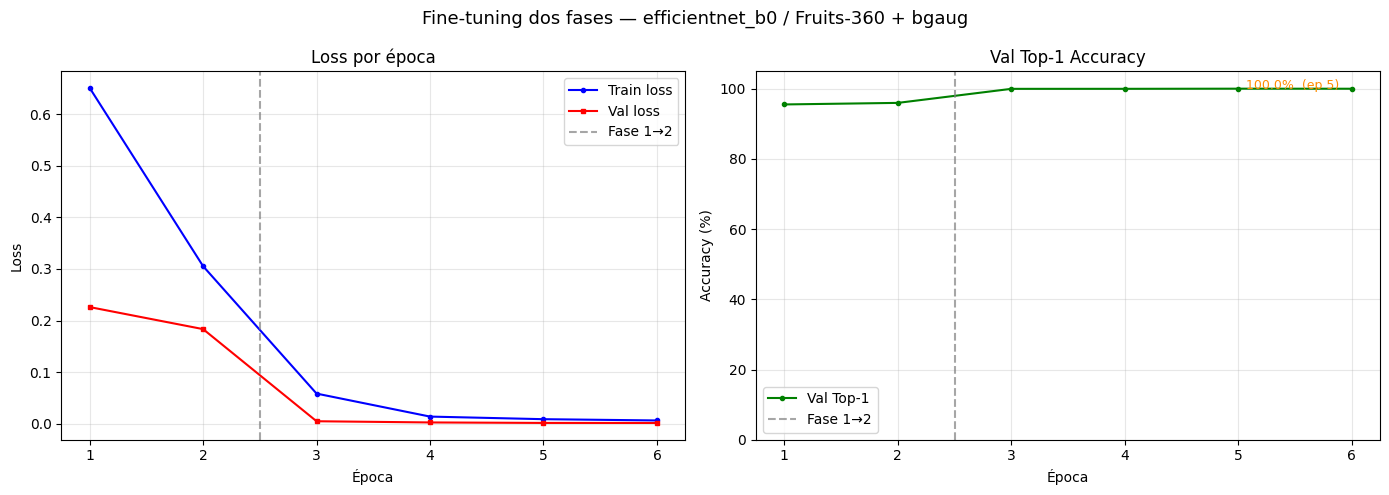

Gráfica guardada en modelo_entrenado\curvas_entrenamiento.png


In [31]:
# CELDA 13 — Curvas de entrenamiento

import matplotlib.pyplot as plt

if historia_completa is None:
    print('Sin historia (ENTRENAR=False). Salta esta celda.')
else:
    hist   = historia_completa
    epocas = list(range(1, len(hist['val_acc']) + 1))
    sep    = hist.get('fase1_epocas', EPOCHS_FASE1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Fine-tuning dos fases — {MODELO_BASE} / Fruits-360 + bgaug', fontsize=13)

    ax1.plot(epocas, hist['train_loss'], 'b-o', markersize=3, label='Train loss')
    ax1.plot(epocas, hist['val_loss'],   'r-s', markersize=3, label='Val loss')
    ax1.axvline(sep + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fase 1→2')
    ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss por época'); ax1.legend(); ax1.grid(True, alpha=0.3)

    acc_pct = [v * 100 for v in hist['val_acc']]
    ax2.plot(epocas, acc_pct, 'g-o', markersize=3, label='Val Top-1')
    ax2.axvline(sep + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fase 1→2')
    best_ep = acc_pct.index(max(acc_pct)) + 1
    ax2.annotate(f'  {max(acc_pct):.1f}%  (ep {best_ep})',
                 xy=(best_ep, max(acc_pct)), fontsize=9, color='darkorange')
    ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Val Top-1 Accuracy'); ax2.set_ylim(0, 105)
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out_png = os.path.join(OUTPUT_DIR, 'curvas_entrenamiento.png')
    plt.savefig(out_png, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gráfica guardada en {out_png}')


In [32]:
# CELDA 14 - Exportar a ONNX para poder usarlo en la raspberry
import onnx

model.eval()
model_cpu = model.cpu()
dummy = torch.randn(1, 3, 224, 224)

onnx_path = os.path.join(OUTPUT_DIR, 'modelo_frutas.onnx')
torch.onnx.export(
    model_cpu,
    dummy,
    onnx_path,
    export_params = True,
    opset_version = 18,
    input_names = ['images'],
    output_names = ['output'],
    dynamic_axes = {'images': {0: 'batch'}, 'output': {0: 'batch'}},
)
print(f'ONNX exportado: {onnx_path}  ({os.path.getsize(onnx_path)/1e6:.1f} MB)')

try:
    import onnxsim
    model_simp, ok = onnxsim.simplify(onnx_path)
    if ok:
        onnx.save(model_simp, onnx_path)
        print(f'ONNX simplificado con onnxsim  ({os.path.getsize(onnx_path)/1e6:.1f} MB)')
except ImportError:
    pass

model = model.to(device)
out_name = 'output'


C:\Users\marcos\AppData\Local\Temp\ipykernel_10492\1837023739.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0614 23:45:08.157000 10492 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX exportado: modelo_entrenado\modelo_frutas.onnx  (0.7 MB)
ONNX simplificado con onnxsim  (16.2 MB)


In [36]:
# CELDA 15 - Verificar el modelo ONNX con onnxruntime
import onnxruntime as ort

session  = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
in_name  = session.get_inputs()[0].name
out_name = session.get_outputs()[0].name

print(f'Input: "{in_name}" - shape={session.get_inputs()[0].shape}')
print(f'Output: "{out_name}" - shape={session.get_outputs()[0].shape}')

# Dummy con preprocesado ImageNet (lo que usará detector_frescos.py)
dummy  = np.random.rand(1, 3, 224, 224).astype(np.float32)
logits = session.run([out_name], {in_name: dummy})[0]
pred_idx = int(np.argmax(logits[0]))
print(f'\nInferencia OK — prediccion dummy: idx={pred_idx}  clase="{class_names[pred_idx]}"')
print(f'\nPreprocesado para detector_frescos.py:')
print(f'  preprocessing : "imagenet"  (img/255 + mean/std ImageNet)')
print(f'  output_node : "{out_name}"')


Input: "images" - shape=['batch', 3, 224, 224]
Output: "output" - shape=['batch', 34]

Inferencia OK — prediccion dummy: idx=11  clase="Cherry"

Preprocesado para detector_frescos.py:
  preprocessing : "imagenet"  (img/255 + mean/std ImageNet)
  output_node : "output"


In [37]:
# CELDA 16 - Guardar JSON de etiquetas

LABELS_PATH = os.path.join(OUTPUT_DIR, 'modelo_frutas_labels.json')

# ImageFolder ordena las clases alfabéticamente
idx_to_class = {str(i): name for i, name in enumerate(class_names)}

labels_data = {
    'idx_to_class': idx_to_class,
    'num_classes': len(class_names),
    'img_size': 224,
    'model': MODELO_BASE,
    'dataset': 'Fruits-360 + bgaug',
    'val_acc': round(float(best_val_top1), 4),
    'preprocessing': 'imagenet',
    'output_node': out_name,
}

with open(LABELS_PATH, 'w', encoding='utf-8') as f:
    json.dump(labels_data, f, ensure_ascii=False, indent=2)

print(f'Labels guardados : {LABELS_PATH}')
print(f'Clases : {len(class_names)}')
print(f'Val Top-1 : {best_val_top1:.1%}')
print(f'Modelo : {MODELO_BASE}')
print(f'Output node : "{out_name}"')


Labels guardados : modelo_entrenado\modelo_frutas_labels.json
Clases : 34
Val Top-1 : 100.0%
Modelo : efficientnet_b0
Output node : "output"


In [40]:
# ------------------------------------------------------------------
# CELDA 17 — Copiar a edge/hardware/modelos/ y mostrar resumen
# ------------------------------------------------------------------
import shutil

destino_edge = os.path.join('edge', 'hardware', 'modelos')
os.makedirs(destino_edge, exist_ok=True)

archivos = [
    (str(onnx_path), os.path.join(destino_edge, 'modelo_frutas.onnx')),
    (LABELS_PATH,    os.path.join(destino_edge, 'modelo_frutas_labels.json')),
]


print('Archivos generados')
for src, dst in archivos:
    if os.path.exists(src):
        size = os.path.getsize(src) / 1e6
        shutil.copy2(src, dst)
        print(f'  {src}  ({size:.1f} MB)')
        print(f'    -> copiado a {dst}')

print()
print('El modelo esta listo en edge/hardware/modelos/')
print('detector_frescos.py lo detectara en el proximo arranque.')

Archivos generados
  modelo_entrenado\modelo_frutas.onnx  (16.2 MB)
    -> copiado a edge\hardware\modelos\modelo_frutas.onnx
  modelo_entrenado\modelo_frutas_labels.json  (0.0 MB)
    -> copiado a edge\hardware\modelos\modelo_frutas_labels.json

El modelo esta listo en edge/hardware/modelos/
detector_frescos.py lo detectara en el proximo arranque.
